# Notebook 02: Alineamiento Multiple de Secuencias (MSA) y Mapa de Posiciones

**Hito 2 del TFM** - Alineamiento multiple de KRAS, HRAS y NRAS, construccion del mapa de equivalencias posicion-a-posicion e identificacion de posiciones recurrentemente mutadas.

---

## Que es un Alineamiento Multiple de Secuencias (MSA)?

Un **alineamiento multiple de secuencias** (Multiple Sequence Alignment, MSA) es una disposicion de tres o mas secuencias biologicas (proteinas o acidos nucleicos) en columnas, de modo que cada columna agrupa residuos que comparten **origen evolutivo comun** u ocupan el **mismo lugar en la estructura tridimensional**.

Los algoritmos de MSA introducen **gaps** (`-`) en las secuencias cuando una de ellas presenta una insercion o delecion respecto a las demas, asegurandose de que los residuos homologos queden alineados verticalmente. La calidad del alineamiento se mide mediante funciones de puntuacion basadas en matrices de sustitucion (como BLOSUM62 para proteinas) y penalizaciones por gaps.

---

## Por que alineamos KRAS, HRAS y NRAS?

Las tres isoformas de la familia RAS son **genes paralogos**: surgieron por duplicacion del mismo gen ancestral durante la evolucion de los vertebrados. Sus dominios cataliticos G comparten una identidad de secuencia superior al 85 %, lo que significa que mas de 8 de cada 10 posiciones tienen exactamente el mismo aminoacido.

Sin embargo, existen **diferencias puntuales** que pueden:

- Alterar la velocidad intrinseca de hidrolisis del GTP.
- Modificar la afinidad por distintos efectores (RAF, PI3K, RalGDS).
- Determinar la localizacion subcelular a traves de la region hipervariable C-terminal.

Para comparar correctamente las mutaciones oncogenicas entre isoformas (por ejemplo, saber si "KRAS G12" y "NRAS G12" son la **misma posicion estructural**) necesitamos un MSA que establezca un **mapa de equivalencias** posicion-a-posicion.

---

## Que informacion obtenemos?

De este notebook extraemos tres artefactos clave:

| Artefacto | Fichero de salida | Descripcion |
|-----------|------------------|-------------|
| MSA en formato FASTA | `data/processed/msa_ras.fasta` | Las tres secuencias alineadas con gaps |
| Mapa posicional | `data/processed/position_map.csv` | Tabla de equivalencias columna por columna |
| Posiciones recurrentes | `data/processed/recurrent_positions.csv` | Hotspots mutados en 2 o mas isoformas |
| Figura del MSA | `figures/02_msa_overview.png` | Visualizacion coloreada del alineamiento |

---

## Prerequisitos

Este notebook **requiere** que el notebook 01 haya sido ejecutado previamente y haya generado:

- `data/processed/cosmic_curated.csv` (dataset de mutaciones curadas de COSMIC)

## Outputs esperados

- `data/processed/msa_ras.fasta`
- `data/processed/position_map.csv`
- `data/processed/recurrent_positions.csv`

Controles obligatorios: G12, G13 y Q61 deben poder localizarse en los tres miembros de RAS.

## 1. Importaciones y configuracion de rutas

En esta primera celda cargamos todas las bibliotecas necesarias y configuramos las rutas del proyecto. Separar las importaciones al inicio del notebook es una buena practica porque facilita identificar las dependencias del analisis y reproducirlo en otros entornos.

La funcion `project_root()` del modulo `tfm_ras.config` nos permite construir rutas absolutas desde la raiz del proyecto, lo que hace el notebook portable: funcionara independientemente de desde que directorio se ejecute Jupyter.

In [1]:
# ============================================================
# CHUNK 1.1: Importaciones y configuración general
# ============================================================

import warnings                    # Modulo estandar para capturar y gestionar advertencias de ejecucion
from pathlib import Path           # Rutas orientadas a objetos, multiplataforma (Linux/Mac/Windows)

import pandas as pd                # Manipulacion de datos tabulares (DataFrames)
from Bio import AlignIO            # Lectura y escritura de ficheros de alineamiento en BioPython

# Importaciones del paquete propio del TFM
from tfm_ras.config import load_config, project_root   # Carga de configuracion YAML y ruta raiz del proyecto
from tfm_ras.alignment import (                        # Funciones del modulo de alineamiento
    fetch_uniprot_sequence,        # Descarga secuencias de UniProt con cache local
    run_msa,                       # Ejecuta el alineamiento multiple de secuencias
    build_position_map,            # Construye el mapa de equivalencias posicion-a-posicion
    find_recurrent_positions,      # Identifica posiciones mutadas en multiples isoformas
    visualize_msa,                 # Genera la figura del alineamiento coloreada
    identity_fraction,             # Calcula la fraccion de identidad media por pares
    consensus_sequence,            # Calcula la secuencia consenso del MSA
)

print("[OK] Bibliotecas importadas correctamente.")

[OK] Bibliotecas importadas correctamente.


In [2]:
# ============================================================
# CHUNK 1.2: Configuracion de rutas absolutas del proyecto
# ============================================================

# project_root() devuelve un objeto Path con la ruta absoluta a la raiz del proyecto.
# Usamos esta funcion en lugar de rutas relativas ('./../') para que el notebook
# funcione correctamente independientemente del directorio de trabajo actual.
ROOT = project_root()

# Directorio con los ficheros FASTA de las secuencias canonicas descargadas de UniProt
SEQ_DIR = ROOT / "data" / "external" / "sequences"

# Directorio de datos procesados donde se guardan los resultados intermedios del pipeline
PROCESSED_DIR = ROOT / "data" / "processed"

# Directorio de figuras del proyecto
FIGURES_DIR = ROOT / "figures"

# Ruta del fichero CSV curado generado por el notebook 01 (prerequisito obligatorio)
COSMIC_CURATED_PATH = PROCESSED_DIR / "cosmic_curated.csv"

# Ruta de salida para el MSA en formato FASTA
MSA_OUTPUT_PATH = PROCESSED_DIR / "msa_ras.fasta"

# Ruta de salida para el mapa posicional en formato CSV
POSITION_MAP_PATH = PROCESSED_DIR / "position_map.csv"

# Ruta de salida para la tabla de posiciones recurrentes
RECURRENT_PATH = PROCESSED_DIR / "recurrent_positions.csv"

# Ruta de salida para la figura del MSA
FIGURE_MSA_PATH = FIGURES_DIR / "02_msa_overview.png"

# Crear los directorios de salida si no existen
# parents=True: crea todos los directorios intermedios necesarios
# exist_ok=True: no lanza error si el directorio ya existe
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"[OK] Raiz del proyecto : {ROOT}")
print(f"[OK] Directorio de secuencias : {SEQ_DIR}")
print(f"[OK] Directorio de resultados : {PROCESSED_DIR}")

[OK] Raiz del proyecto : /Users/rachi/Desktop/TFM/tfm_ras_mutations
[OK] Directorio de secuencias : /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/external/sequences
[OK] Directorio de resultados : /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed


In [3]:
# ============================================================
# CHUNK 1.3: Opciones de visualizacion de pandas
# ============================================================

# pd.set_option() permite configurar el comportamiento de visualizacion de pandas.
# Estos ajustes son globales para toda la sesion del notebook.

# display.max_rows: numero maximo de filas que se muestran al imprimir un DataFrame.
# Valor 20 permite ver suficientes filas sin saturar la salida.
pd.set_option("display.max_rows", 50)

# display.max_columns: None significa que se muestran todas las columnas sin truncar.
# Por defecto pandas trunca columnas si son muchas; None desactiva ese limite.
pd.set_option("display.max_columns", None)

# display.width: ancho maximo en caracteres para la representacion del DataFrame.
# 120 caracteres se adapta bien a pantallas modernas sin romper las columnas.
pd.set_option("display.width", 120)

# display.float_format: formato para mostrar numeros de punto flotante.
# '{:.4f}'.format formatea con 4 decimales, lo que es suficiente para fracciones de identidad.
pd.set_option("display.float_format", "{:.4f}".format)

print("[OK] Opciones de visualizacion de pandas configuradas.")

[OK] Opciones de visualizacion de pandas configuradas.


## 2. Carga de la configuracion y del dataset curado

La configuracion del proyecto (`configs/config.yaml`) centraliza todos los parametros del analisis: identificadores UniProt de las tres isoformas, umbrales de frecuencia para considerar una posicion como recurrente, coordenadas de las regiones funcionales, etc.

El dataset curado (`data/processed/cosmic_curated.csv`) fue generado en el notebook 01 a partir del fichero COSMIC crudo. Contiene las mutaciones missense somaticas confirmadas para KRAS, HRAS y NRAS, con columnas normalizadas que incluyen: `gene`, `position`, `wt_aa`, `mut_aa`, `hgvs_p`, `sample_count`, `tumour_types`, `primary_tissues`.

**Importante:** si la celda siguiente lanza `FileNotFoundError`, ejecuta primero el notebook 01 para generar `cosmic_curated.csv`.

In [4]:
# ============================================================
# CHUNK 2.1: Cargar la configuracion YAML del proyecto
# ============================================================

# load_config() lee el fichero configs/config.yaml y lo convierte en un
# diccionario Python. Lanza FileNotFoundError si el YAML no existe.
CFG = load_config(ROOT / 'configs' / 'config.yaml')

# Extraemos los identificadores UniProt de cada isoforma RAS desde la configuracion.
# cfg["family"]["members"] es un dict con claves "KRAS", "HRAS", "NRAS".
# Para cada gen extraemos el campo "uniprot_id" (e.g. "P01116" para KRAS).
uniprot_ids = {
    gene: info["uniprot_id"]
    for gene, info in CFG["family"]["members"].items()
}

# Extraemos los umbrales de recurrencia definidos en la configuracion.
# recurrent_min_members: numero minimo de isoformas con mutaciones en la misma posicion.
# recurrent_min_samples_per_member: numero minimo de muestras tumorales por isoforma.
MIN_MEMBERS = CFG["thresholds"]["recurrent_min_members"]
MIN_SAMPLES = CFG["thresholds"]["recurrent_min_samples_per_member"]

# Extraemos los hotspots oncogenicos clave definidos en la configuracion.
# Cada elemento del listado es un dict con "position" (int) y "residue" (str).
hotspots_cfg = CFG["hotspots"]

print("[OK] Configuracion cargada.")
print(f"  Isoformas          : {uniprot_ids}")
print(f"  Umbral min_members : {MIN_MEMBERS}")
print(f"  Umbral min_samples : {MIN_SAMPLES}")
print(f"  Hotspots           : {hotspots_cfg}")

[OK] Configuracion cargada.
  Isoformas          : {'KRAS': 'P01116', 'HRAS': 'P01112', 'NRAS': 'P01111'}
  Umbral min_members : 2
  Umbral min_samples : 10
  Hotspots           : [{'position': 12, 'residue': 'G'}, {'position': 13, 'residue': 'G'}, {'position': 61, 'residue': 'Q'}]


In [5]:
# ============================================================
# CHUNK 2.2: Verificar y cargar el dataset curado del Hito 1
# ============================================================

# Verificamos que el fichero curado existe antes de intentar cargarlo.
# Si no existe, el mensaje de error indica claramente que hay que ejecutar el notebook 01.
if not COSMIC_CURATED_PATH.is_file():
    raise FileNotFoundError(
        f"No se encontro el fichero curado: {COSMIC_CURATED_PATH}\n"
        "Ejecuta primero el notebook 01 para generarlo."
    )

# pd.read_csv() carga el fichero CSV en un DataFrame de pandas.
# El separador por defecto es ',' (coma), que es el utilizado por to_csv() de pandas.
curated = pd.read_csv(COSMIC_CURATED_PATH)

# Mostrar un resumen del dataset cargado para confirmar su estructura.
print(f"[OK] Dataset curado cargado desde: {COSMIC_CURATED_PATH}")
print(f"  Filas      : {len(curated):,}")
print(f"  Columnas   : {list(curated.columns)}")
print()

# Mostrar la distribucion de mutaciones por gen usando value_counts().
# value_counts() cuenta cuantas filas tiene cada valor unico de la columna indicada.
print("Mutaciones por gen:")
print(curated["gene"].value_counts().to_string())

[OK] Dataset curado cargado desde: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/cosmic_curated.csv
  Filas      : 469
  Columnas   : ['gene', 'uniprot_id', 'position', 'wt_aa', 'mut_aa', 'hgvs_p', 'sample_count', 'tumor_types', 'primary_tissues', 'cosmic_version']

Mutaciones por gen:
gene
KRAS    207
NRAS    133
HRAS    129


In [6]:
# ============================================================
# CHUNK 2.3: Inspeccion visual de las primeras filas del dataset
# ============================================================

# groupby.('gene').head(5) devuelve las primeras 5 filas del DataFrame por gen.
# En Jupyter Notebook, el ultimo objeto evaluado en una celda se muestra
# automaticamente como tabla HTML enriquecida; por eso no hace falta print().
display(curated.groupby('gene').head(5))

,gene,uniprot_id,position,wt_aa,mut_aa,hgvs_p,sample_count,tumor_types,primary_tissues,cosmic_version
0,KRAS,P01116,12,G,D,p.G12D,4697,Ewing_sarcoma-peripheral_primitive_neuroectode...,NS | autonomic_ganglia | biliary_tract | bone ...,v104
1,KRAS,P01116,12,G,V,p.G12V,3625,Wilms_tumour | aberrant_crypt_foci | adenoma |...,NS | autonomic_ganglia | biliary_tract | breas...,v104
2,KRAS,P01116,13,G,D,p.G13D,1716,NS | aberrant_crypt_foci | adenoma | angiosarc...,NS | biliary_tract | breast | cervix | endomet...,v104
3,KRAS,P01116,12,G,C,p.G12C,1345,aberrant_crypt_foci | adenoma | angiosarcoma |...,NS | biliary_tract | breast | cervix | endomet...,v104
4,KRAS,P01116,12,G,A,p.G12A,728,aberrant_crypt_foci | adenoma | carcinoid-endo...,NS | autonomic_ganglia | biliary_tract | breas...,v104
207,HRAS,P01112,13,G,R,p.G13R,240,adnexal_tumour | benign_melanocytic_nevus | ca...,adrenal_gland | autonomic_ganglia | breast | l...,v104
208,HRAS,P01112,61,Q,R,p.Q61R,214,angiosarcoma | benign_melanocytic_nevus | carc...,adrenal_gland | autonomic_ganglia | breast | g...,v104
209,HRAS,P01112,61,Q,K,p.Q61K,84,adenoma-nodule-goitre | carcinoma | germ_cell_...,adrenal_gland | autonomic_ganglia | bone | bre...,v104
210,HRAS,P01112,12,G,S,p.G12S,64,carcinoma | malignant_melanoma | other | rhabd...,bone | endometrium | large_intestine | oesopha...,v104
211,HRAS,P01112,61,Q,L,p.Q61L,64,angiosarcoma | benign_melanocytic_nevus | carc...,breast | central_nervous_system | liver | lung...,v104


## 3. Descarga y carga de secuencias canonicas desde UniProt

Las secuencias canonicas de las proteinas RAS provienen de **UniProt** (Universal Protein Resource, https://www.uniprot.org), la base de datos de referencia para secuencias y anotaciones de proteinas. Cada isoforma tiene un identificador de acceso unico:

| Gen | UniProt ID | Nombre | Longitud (aa) |
|-----|-----------|--------|---------------|
| KRAS | P01116 | GTPase KRas | 189 |
| HRAS | P01112 | GTPase HRas | 189 |
| NRAS | P01111 | GTPase NRas | 189 |

La funcion `fetch_uniprot_sequence()` implementa una estrategia de **cache local**: si el fichero FASTA ya existe en `data/external/sequences/`, lo lee del disco sin hacer ninguna peticion de red. Esto hace que las siguientes ejecuciones del notebook sean instantaneas y no dependan de disponibilidad de internet.

El formato **FASTA** (del acronimo FAST-All) es el estandar de facto para representar secuencias biologicas. Cada entrada consiste en:
- Una linea de cabecera que empieza por `>` con el identificador y descripcion.
- Una o mas lineas con la secuencia de aminoacidos en codigo de una letra.

La funcion devuelve directamente la secuencia como cadena de texto (sin cabecera), lista para usar en el alineamiento.

In [7]:
# ============================================================
# CHUNK 3.1: Descargar o cargar desde cache las secuencias UniProt
# ============================================================

# Construimos el diccionario de secuencias {nombre_gen -> secuencia_aminoacidos}.
# Las claves DEBEN ser exactamente "KRAS", "HRAS", "NRAS" para que run_msa()
# reconozca las tres isoformas y use el camino optimizado sin herramienta externa.
# fetch_uniprot_sequence() devuelve una cadena de texto con la secuencia completa
# de aminoacidos en codigo de una letra (e.g. "MTEYKLVVVGAGGVGKS...").
sequences = {
    gene: fetch_uniprot_sequence(uniprot_id)
    for gene, uniprot_id in uniprot_ids.items()
}

print("[OK] Secuencias cargadas:")
for gene, seq in sequences.items():
    # Mostramos los primeros 30 residuos como verificacion visual rapida.
    # Todos deben comenzar por 'M' (metionina inicial) si son secuencias canonicas.
    print(f"  {gene}: {len(seq)} aa | primeros 30: {seq[:30]}")

[OK] Secuencias cargadas:
  KRAS: 189 aa | primeros 30: MTEYKLVVVGAGGVGKSALTIQLIQNHFVD
  HRAS: 189 aa | primeros 30: MTEYKLVVVGAGGVGKSALTIQLIQNHFVD
  NRAS: 189 aa | primeros 30: MTEYKLVVVGAGGVGKSALTIQLIQNHFVD


In [8]:
# ============================================================
# CHUNK 3.2: Verificacion de longitudes y residuos clave
# ============================================================

# Verificar que las tres secuencias tienen la misma longitud (189 aminoacidos).
# Las tres isoformas RAS tienen exactamente 189 residuos en su secuencia canonica de UniProt.
lengths = {gene: len(seq) for gene, seq in sequences.items()}
print("Longitudes de secuencia:")
for gene, length in lengths.items():
    print(f"  {gene}: {length} aa")

# Verificar que las longitudes son iguales (condicion para el alineamiento sin gaps).
# set() de los valores devuelve un conjunto; si solo tiene un elemento, todas son iguales.
if len(set(lengths.values())) == 1:
    print("\n[OK] Las tres secuencias tienen la misma longitud -> alineamiento sin gaps.")
else:
    print("\n[WARN] Las secuencias tienen longitudes distintas -> se necesitara herramienta externa.")

print()

# Verificar los hotspots clave en la secuencia de KRAS (indexacion 0-based en Python).
# La posicion 12 en la nomenclatura estandar (1-based) corresponde al indice 11 (0-based).
kras_seq = sequences["KRAS"]
print("Verificacion de hotspots en KRAS (indice 0-based = posicion 1-based - 1):")
for hs in hotspots_cfg:
    pos = hs["position"]          # Posicion 1-based estandar
    expected_aa = hs["residue"]   # Aminoacido esperado (G o Q)
    observed_aa = kras_seq[pos - 1]  # pos-1 convierte de 1-based a 0-based
    status = "[OK]" if observed_aa == expected_aa else "[FAIL]"
    print(f"  {status} Posicion {pos}: esperado '{expected_aa}', observado '{observed_aa}'")

Longitudes de secuencia:
  KRAS: 189 aa
  HRAS: 189 aa
  NRAS: 189 aa

[OK] Las tres secuencias tienen la misma longitud -> alineamiento sin gaps.

Verificacion de hotspots en KRAS (indice 0-based = posicion 1-based - 1):
  [OK] Posicion 12: esperado 'G', observado 'G'
  [OK] Posicion 13: esperado 'G', observado 'G'
  [OK] Posicion 61: esperado 'Q', observado 'Q'


## 4. Ejecucion del alineamiento multiple de secuencias (MSA)

### Que algoritmo se usa y por que?

La funcion `run_msa()` soporta tres herramientas de MSA: **ClustalOmega** (`clustalo`), **MAFFT** y **MUSCLE**. Por defecto usa ClustalOmega, que es la opcion mas robusta para proteinas con alta identidad de secuencia.

**ClustalOmega** es el sucesor moderno de ClustalW. Utiliza:
1. **Perfiles HMM** (Hidden Markov Models) para representar la distribucion estadistica de aminoacidos en cada posicion.
2. **Arboles guia** construidos con algoritmos de agrupamiento jerarquico (neighbor-joining) para determinar el orden de alineamiento progresivo.
3. Matrices de distancias basadas en $k$-tuplas para una estimacion rapida de similitud entre secuencias.

Para el caso particular de KRAS, HRAS y NRAS, si las tres secuencias tienen **exactamente la misma longitud** (189 residuos), `run_msa()` utiliza un camino optimizado que construye directamente el alineamiento **sin gaps**, sin necesidad de invocar ninguna herramienta externa. Esto es biologicamente correcto: las tres isoformas tienen la misma longitud en su dominio catalytico G y los residuos homologos se corresponden posicion a posicion.

El modulo emitira una advertencia informativa indicando que se usa el alineamiento sin gaps. Esto es **el comportamiento esperado** y no indica ningun error.

In [9]:
# ============================================================
# CHUNK 4.1: Ejecutar el alineamiento multiple de secuencias
# ============================================================

# run_msa() acepta un diccionario {nombre_gen -> secuencia} y el nombre del algoritmo.
# Devuelve un objeto Bio.Align.MultipleSeqAlignment (BioPython) con el alineamiento.

# Como las tres secuencias RAS tienen la misma longitud (189 aa), run_msa() utilizara
# el camino optimizado sin herramienta externa y emitira un UserWarning informativo.
# Capturamos el warning con warnings.catch_warnings() para mostrar un mensaje explicativo
# en lugar de la advertencia tecnica interna.
with warnings.catch_warnings(record=True) as captured_warnings:
    # simplefilter("always") hace que TODOS los warnings se capturen,
    # incluidos los que Python normalmente mostraria solo la primera vez.
    warnings.simplefilter("always")

    # Ejecutar el alineamiento con el algoritmo por defecto (ClustalOmega).
    # Las claves del diccionario son exactamente "KRAS", "HRAS", "NRAS" (coinciden con GENES),
    # lo que activa el camino rapido sin herramienta externa.
    msa = run_msa(sequences, algorithm="clustalo")

# Mostrar los warnings capturados de forma informativa
if captured_warnings:
    for w in captured_warnings:
        print(f"[INFO] Aviso del modulo de alineamiento: {w.message}")

print()
print(f"[OK] MSA generado correctamente.")
print(f"  Tipo del objeto       : {type(msa).__name__}")
print(f"  Numero de secuencias  : {len(msa)}")
print(f"  Longitud del MSA      : {msa.get_alignment_length()} columnas")

[INFO] Aviso del modulo de alineamiento: Secuencias KRAS/HRAS/NRAS de igual longitud; usando alineamiento sin gaps.

[OK] MSA generado correctamente.
  Tipo del objeto       : MultipleSeqAlignment
  Numero de secuencias  : 3
  Longitud del MSA      : 189 columnas


In [10]:
# ============================================================
# CHUNK 4.2: Inspeccion basica del objeto MSA de BioPython
# ============================================================

# Mostrar cada registro del alineamiento.
# Un objeto MultipleSeqAlignment de BioPython es iterable: cada elemento es un SeqRecord.
# SeqRecord tiene atributos .id (identificador), .seq (secuencia) y .description.
print("Registros del alineamiento:")
print("-" * 60)
for record in msa:
    # str(record.seq) convierte la secuencia BioPython a cadena de texto Python estandar.
    seq_str = str(record.seq)

    # Contar el numero de gaps ('-') en la secuencia alineada.
    # .count('-') cuenta las ocurrencias del caracter '-' en la cadena.
    n_gaps = seq_str.count("-")

    # Mostrar el identificador, los primeros 40 residuos y el numero de gaps.
    print(f"  ID: {record.id:<8}  | primeros 40: {seq_str[:40]}  | gaps: {n_gaps}")

print("-" * 60)

Registros del alineamiento:
------------------------------------------------------------
  ID: KRAS      | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY  | gaps: 0
  ID: HRAS      | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY  | gaps: 0
  ID: NRAS      | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY  | gaps: 0
------------------------------------------------------------


## 5. Estadisticas del MSA

Una vez obtenido el alineamiento, calculamos tres estadisticas fundamentales:

1. **Longitud del MSA**: numero total de columnas del alineamiento, incluyendo posiciones con gaps. Para KRAS/HRAS/NRAS, si no hay gaps, la longitud coincide con la longitud de las secuencias (189).

2. **Fraccion de identidad media por pares**: proporcion de posiciones alineadas donde dos secuencias tienen exactamente el mismo aminoacido, promediada sobre todos los pares posibles (KRAS-HRAS, KRAS-NRAS, HRAS-NRAS). Un valor >85 % confirma la alta conservacion de la familia RAS.

3. **Secuencia consenso**: en cada columna del alineamiento se selecciona el aminoacido mas frecuente entre las tres isoformas. La secuencia consenso puede usarse como secuencia de referencia pan-RAS para el diseno de inhibidores.

In [11]:
# ============================================================
# CHUNK 5.1: Calcular estadisticas del alineamiento
# ============================================================

# Longitud total del alineamiento (numero de columnas, incluyendo posiciones con gaps).
# get_alignment_length() es un metodo de MultipleSeqAlignment de BioPython.
aln_length = msa.get_alignment_length()

# Fraccion de identidad media por pares entre todas las secuencias del MSA.
# identity_fraction() calcula la identidad de forma pairwise y devuelve la media.
id_frac = identity_fraction(msa)

# Secuencia consenso: en cada columna se elige el aminoacido mas frecuente.
# consensus_sequence() devuelve una cadena de texto de la misma longitud que el MSA.
consensus = consensus_sequence(msa)

print("Estadisticas del alineamiento multiple de secuencias (MSA):")
print("=" * 55)
print(f"  Longitud del MSA         : {aln_length} columnas")
print(f"  Fraccion de identidad    : {id_frac:.4f} ({id_frac * 100:.2f} %)")
print(f"  Longitud del consenso    : {len(consensus)} residuos")
print()

# Mostrar la secuencia consenso en bloques de 60 residuos para facilitar la lectura.
# Esto imita el formato de los editores de secuencias biologicas como UGENE o BioEdit.
print("Secuencia consenso (bloques de 60 residuos):")
block_size = 60  # Numero de residuos por linea
for start in range(0, len(consensus), block_size):
    # range(0, len, 60) genera indices 0, 60, 120, 180...
    block = consensus[start:start + block_size]  # Extraer el bloque actual
    # Mostrar la posicion inicial (1-based) seguida de los residuos del bloque.
    print(f"  {start + 1:4d}  {block}")

Estadisticas del alineamiento multiple de secuencias (MSA):
  Longitud del MSA         : 189 columnas
  Fraccion de identidad    : 0.8501 (85.01 %)
  Longitud del consenso    : 189 residuos

Secuencia consenso (bloques de 60 residuos):
     1  MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAG
    61  QEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHXYREQIKRVKDSDDVPMVLVGNKCDL
   121  PXRTVDTKQAQDLARSYGIPFIETSAKTRQGVEDAFYTLVREIRQYRLKKLNXXDXXXXG
   181  CMXXKCVXM


In [12]:
# ============================================================
# CHUNK 5.2: Comparar secuencias alineadas por bloques
# ============================================================

# Construir un diccionario de secuencias alineadas como cadenas de texto.
# str(record.seq) convierte el objeto Seq de BioPython a str estandar de Python.
aligned_seqs = {record.id: str(record.seq) for record in msa}

# Definir la lista de genes en el orden de visualizacion.
gene_order = ["KRAS", "HRAS", "NRAS"]

print("Vista del alineamiento multiple:")
print("=" * 65)

# Mostrar bloques de 30 posiciones para los 189 residuos.
for block_start in range(0, 189, 30):
    block_end = min(block_start + 30, 189)
    # Etiqueta del bloque indicando las posiciones MSA (1-based)
    print(f"Posicion MSA {block_start + 1:3d} - {block_end:3d}:")
    for gene in gene_order:
        # Si el gen no tiene registro en el MSA, mostrar mensaje de error
        if gene not in aligned_seqs:
            print(f"  {gene:4s}: [registro no encontrado]")
            continue
        # Extraer el fragmento del bloque actual de la secuencia alineada
        block_seq = aligned_seqs[gene][block_start:block_end]
        print(f"  {gene:4s}: {block_seq}")
    print()

Vista del alineamiento multiple:
Posicion MSA   1 -  30:
  KRAS: MTEYKLVVVGAGGVGKSALTIQLIQNHFVD
  HRAS: MTEYKLVVVGAGGVGKSALTIQLIQNHFVD
  NRAS: MTEYKLVVVGAGGVGKSALTIQLIQNHFVD

Posicion MSA  31 -  60:
  KRAS: EYDPTIEDSYRKQVVIDGETCLLDILDTAG
  HRAS: EYDPTIEDSYRKQVVIDGETCLLDILDTAG
  NRAS: EYDPTIEDSYRKQVVIDGETCLLDILDTAG

Posicion MSA  61 -  90:
  KRAS: QEEYSAMRDQYMRTGEGFLCVFAINNTKSF
  HRAS: QEEYSAMRDQYMRTGEGFLCVFAINNTKSF
  NRAS: QEEYSAMRDQYMRTGEGFLCVFAINNSKSF

Posicion MSA  91 - 120:
  KRAS: EDIHHYREQIKRVKDSEDVPMVLVGNKCDL
  HRAS: EDIHQYREQIKRVKDSDDVPMVLVGNKCDL
  NRAS: ADINLYREQIKRVKDSDDVPMVLVGNKCDL

Posicion MSA 121 - 150:
  KRAS: PSRTVDTKQAQDLARSYGIPFIETSAKTRQ
  HRAS: AARTVESRQAQDLARSYGIPYIETSAKTRQ
  NRAS: PTRTVDTKQAHELAKSYGIPFIETSAKTRQ

Posicion MSA 151 - 180:
  KRAS: RVEDAFYTLVREIRQYRLKKISKEEKTPGC
  HRAS: GVEDAFYTLVREIRQHKLRKLNPPDESGPG
  NRAS: GVEDAFYTLVREIRQYRMKKLNSSDDGTQG

Posicion MSA 181 - 189:
  KRAS: VKIKKCIIM
  HRAS: CMSCKCVLS
  NRAS: CMGLPCVVM



## 6. Construccion del mapa de equivalencias posicion-a-posicion

El **mapa posicional** es la pieza central de este hito. Es una tabla donde cada fila corresponde a una columna del alineamiento y registra:

- `msa_position`: indice 1-based de la columna en el alineamiento.
- `kras_position`, `hras_position`, `nras_position`: posicion 1-based del residuo en cada isoforma (o `NaN` si hay un gap en esa posicion).
- `kras_aa`, `hras_aa`, `nras_aa`: codigo de una letra del aminoacido de cada isoforma.
- `conserved`: `True` si el mismo aminoacido aparece en las tres isoformas sin ningun gap.

Este mapa permite responder preguntas como: *"La posicion KRAS G12 es equivalente a que posicion en HRAS?"* o *"Que fraccion del dominio G esta conservada entre las tres isoformas?"*.

La funcion `build_position_map()` tambien valida automaticamente que los hotspots G12, G13 y Q61 estan correctamente alineados (mismo aminoacido y misma posicion numerica en las tres isoformas). Si la validacion falla, lanza una excepcion descriptiva que indica el problema.

In [13]:
# ============================================================
# CHUNK 6.1: Construir el mapa de equivalencias posicion-a-posicion
# ============================================================

# build_position_map() recibe el objeto MSA de BioPython y devuelve un DataFrame
# con las columnas definidas en POSITION_MAP_COLUMNS del modulo alignment.py.
# Ademas valida internamente que G12, G13 y Q61 estan alineados correctamente.
position_map = build_position_map(msa)

print(f"[OK] Mapa posicional construido.")
print(f"  Filas (columnas del MSA) : {len(position_map)}")
print(f"  Columnas                 : {list(position_map.columns)}")
print()

# Calcular el porcentaje de posiciones completamente conservadas.
# .sum() sobre una columna booleana cuenta el numero de True.
n_conserved = position_map["conserved"].sum()
pct_conserved = n_conserved / len(position_map) * 100
print(f"  Posiciones conservadas   : {n_conserved} de {len(position_map)} ({pct_conserved:.1f} %)")

# Calcular el numero de posiciones con algun gap.
# .isna() devuelve True donde el valor es NaN; .any(axis=1) es True si alguna columna es True.
# Pero como las tres secuencias tienen la misma longitud, no habra gaps en este caso.
pos_columns = ["kras_position", "hras_position", "nras_position"]
n_with_gaps = position_map[pos_columns].isna().any(axis=1).sum()
print(f"  Posiciones con algun gap : {n_with_gaps}")

[OK] Mapa posicional construido.
  Filas (columnas del MSA) : 189
  Columnas                 : ['msa_position', 'kras_position', 'hras_position', 'nras_position', 'kras_aa', 'hras_aa', 'nras_aa', 'conserved']

  Posiciones conservadas   : 152 de 189 (80.4 %)
  Posiciones con algun gap : 0


In [14]:
# ============================================================
# CHUNK 6.2: Inspeccion del mapa posicional
# ============================================================

# .head() muestra las primeras 10 filas del DataFrame.
# Estas corresponden a las primeras 10 posiciones del alineamiento (region N-terminal).
print("Primeras 10 filas del mapa posicional:")

# Posiciones del dominio G que tienen diferentes aminoácidos en sus 3 isoformas
gdomain_variable_positions = position_map[
    (position_map['msa_position'].between(1, 166)) 
    & (position_map['kras_aa']!= position_map['hras_aa'])
    & (position_map['kras_aa']!= position_map['nras_aa'])
    & (position_map['hras_aa']!= position_map['nras_aa'])
]

display(position_map.head(10).style.hide(axis="index"))


print("Posiciones del dominio G con divergencia entre KRAS, HRAS y NRAS:")
display(gdomain_variable_positions[['msa_position']].style.hide(axis="index"))

Primeras 10 filas del mapa posicional:


msa_position,kras_position,hras_position,nras_position,kras_aa,hras_aa,nras_aa,conserved
1,1,1,1,M,M,M,True
2,2,2,2,T,T,T,True
3,3,3,3,E,E,E,True
4,4,4,4,Y,Y,Y,True
5,5,5,5,K,K,K,True
6,6,6,6,L,L,L,True
7,7,7,7,V,V,V,True
8,8,8,8,V,V,V,True
9,9,9,9,V,V,V,True
10,10,10,10,G,G,G,True


Posiciones del dominio G con divergencia entre KRAS, HRAS y NRAS:


msa_position
95
122


In [15]:
# ============================================================
# CHUNK 6.3: Ultimas filas del mapa posicional
# ============================================================

# .tail() muestra las ultimas 10 filas del DataFrame.
# Estas corresponden a la region C-terminal de las secuencias, incluyendo la
# region hipervariable donde las isoformas divergen mas entre si.
print("Ultimas 10 filas del mapa posicional:")
display(position_map.tail(10).style.hide(axis="index"))

Ultimas 10 filas del mapa posicional:


msa_position,kras_position,hras_position,nras_position,kras_aa,hras_aa,nras_aa,conserved
180,180,180,180,C,G,G,False
181,181,181,181,V,C,C,False
182,182,182,182,K,M,M,False
183,183,183,183,I,S,G,False
184,184,184,184,K,C,L,False
185,185,185,185,K,K,P,False
186,186,186,186,C,C,C,True
187,187,187,187,I,V,V,False
188,188,188,188,I,L,V,False
189,189,189,189,M,S,M,False


## 7. Verificacion de hotspots oncogenicos G12, G13 y Q61

Los tres hotspots oncogenicos mas importantes de la familia RAS son:

- **G12 (Glicina 12, P-loop)**: la glicina en la posicion 12 es critica para la geometria del P-loop (bucle de union al fosfato del GTP). Su reducido tamano permite una configuracion conformacional especifica que no puede ser adoptada por ningun otro aminoacido. Mutaciones en G12 (principalmente G12D, G12V, G12C) impiden la interaccion con las proteinas GAP que normalmente estimulan la hidrolisis del GTP, bloqueando RAS en su estado activo unido a GTP.

- **G13 (Glicina 13, P-loop)**: similar a G12, las mutaciones en G13 (principalmente G13D) tienen el mismo mecanismo pero con diferentes propiedades cineticas. G13D es la segunda mutacion mas frecuente de KRAS en cancer colorrectal.

- **Q61 (Glutamina 61, Switch II)**: la glutamina en la posicion 61 participa directamente en el mecanismo de hidrolisis del GTP mediante un ataque nucleofilico catalizado por agua. Mutaciones en Q61 (principalmente Q61R, Q61K, Q61L) eliminan esta actividad catalitica, manteniendo RAS en estado activo indefinidamente.

Para que el mapa posicional sea correcto, las tres isoformas deben tener exactamente **G en las posiciones 12 y 13** y **Q en la posicion 61** en la misma columna del MSA.

In [16]:
# ============================================================
# CHUNK 7.1: Verificar alineamiento de hotspots G12, G13, Q61
# ============================================================

# Definir los hotspots a verificar: posicion en KRAS y aminoacido esperado.
# Estos valores coinciden con los definidos en configs/config.yaml.
hotspots_to_check = [(hs["position"], hs["residue"]) for hs in hotspots_cfg]

print("Verificacion de alineamiento de hotspots oncogenicos:")
print("=" * 70)
print(f"  {'Hotspot':<10} {'MSA col':<10} {'KRAS':<12} {'HRAS':<12} {'NRAS':<12} {'Estado'}")
print("-" * 70)

all_ok = True  # Bandera para detectar si algun hotspot falla la verificacion

for position, expected_aa in hotspots_to_check:
    # Filtrar el mapa posicional para obtener la fila con kras_position == position.
    # .eq(position) es equivalente a == position pero es seguro con NaN.
    rows = position_map.loc[position_map["kras_position"].eq(position)]

    if rows.empty:
        print(f"  {expected_aa}{position:<9} {'N/A':<10} {'NO ENCONTRADO':<36} [FAIL]")
        all_ok = False
        continue

    # .iloc[0] toma la primera fila del DataFrame filtrado.
    # En este caso solo debe haber una fila por cada posicion de KRAS.
    row = rows.iloc[0]

    # Extraer las columnas relevantes de la fila
    msa_col = int(row["msa_position"])  # Columna en el MSA (1-based)
    kras_info = f"{row['kras_aa']}{int(row['kras_position'])}"  # e.g. "G12"
    hras_info = f"{row['hras_aa']}{int(row['hras_position'])}"  # e.g. "G12"
    nras_info = f"{row['nras_aa']}{int(row['nras_position'])}"  # e.g. "G12"

    # Verificar que los tres aminoacidos son el esperado
    all_correct = (
        row["kras_aa"] == expected_aa and
        row["hras_aa"] == expected_aa and
        row["nras_aa"] == expected_aa
    )

    status = "[OK]" if all_correct else "[FAIL]"
    if not all_correct:
        all_ok = False

    print(f"  {expected_aa}{position:<9} {msa_col:<10} {kras_info:<12} {hras_info:<12} {nras_info:<12} {status}")

print("-" * 70)
if all_ok:
    print("\n[OK] Los tres hotspots estan correctamente alineados en las tres isoformas.")
else:
    print("\n[FAIL] Alguno de los hotspots no esta correctamente alineado. Revisar el MSA.")

Verificacion de alineamiento de hotspots oncogenicos:
  Hotspot    MSA col    KRAS         HRAS         NRAS         Estado
----------------------------------------------------------------------
  G12        12         G12          G12          G12          [OK]
  G13        13         G13          G13          G13          [OK]
  Q61        61         Q61          Q61          Q61          [OK]
----------------------------------------------------------------------

[OK] Los tres hotspots estan correctamente alineados en las tres isoformas.


## 8. Guardar el MSA en formato FASTA

El fichero FASTA del alineamiento se guarda en `data/processed/msa_ras.fasta` para su uso en pasos posteriores del pipeline (analisis estructural, calculo de conservacion por posicion, etc.).

La funcion `AlignIO.write()` de BioPython escribe el alineamiento en un formato especificado. El formato `"fasta"` produce un fichero FASTA estandar donde cada secuencia alineada incluye los caracteres `-` que representan los gaps.

**Sintaxis:** `AlignIO.write(alignment, handle, format)` donde:
- `alignment`: el objeto `MultipleSeqAlignment` a escribir.
- `handle`: ruta del fichero de salida (como cadena de texto) o un objeto fichero abierto.
- `format`: nombre del formato de alineamiento (`"fasta"`, `"clustal"`, `"phylip"`, etc.).
- **Devuelve**: el numero de alineamientos escritos (normalmente 1).

In [17]:
# ============================================================
# CHUNK 8.1: Guardar el MSA en formato FASTA
# ============================================================

# AlignIO.write() escribe el alineamiento en el fichero de salida especificado.
# str(MSA_OUTPUT_PATH) convierte el objeto Path a cadena de texto, necesario para
# garantizar compatibilidad con versiones antiguas de BioPython que no aceptan Path.
# El formato "fasta" produce un fichero FASTA con gaps ('-') para cada secuencia.
n_written = AlignIO.write(msa, str(MSA_OUTPUT_PATH), "fasta")

print(f"[OK] MSA guardado en: {MSA_OUTPUT_PATH}")
print(f"  Alineamientos escritos: {n_written}")

# Verificar que el fichero se creo correctamente comprobando su existencia y tamano.
# .stat().st_size devuelve el tamano del fichero en bytes.
file_size = MSA_OUTPUT_PATH.stat().st_size
print(f"  Tamano del fichero    : {file_size} bytes")

[OK] MSA guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/msa_ras.fasta
  Alineamientos escritos: 1
  Tamano del fichero    : 597 bytes


In [18]:
# ============================================================
# CHUNK 8.2: Verificar la lectura del MSA guardado
# ============================================================

# Releer el fichero guardado para confirmar que se escribio correctamente.
# AlignIO.read() carga un unico alineamiento desde un fichero en el formato indicado.
# Si el fichero contiene multiples alineamientos, habria que usar AlignIO.parse().
msa_reloaded = AlignIO.read(str(MSA_OUTPUT_PATH), "fasta")

print("[OK] MSA verificado por lectura:")
print(f"  Numero de secuencias  : {len(msa_reloaded)}")
print(f"  Longitud del MSA      : {msa_reloaded.get_alignment_length()} columnas")
for record in msa_reloaded:
    print(f"  ID: {record.id:<8} | longitud: {len(record.seq)} | primeros 20: {str(record.seq)[:20]}")

[OK] MSA verificado por lectura:
  Numero de secuencias  : 3
  Longitud del MSA      : 189 columnas
  ID: KRAS     | longitud: 189 | primeros 20: MTEYKLVVVGAGGVGKSALT
  ID: HRAS     | longitud: 189 | primeros 20: MTEYKLVVVGAGGVGKSALT
  ID: NRAS     | longitud: 189 | primeros 20: MTEYKLVVVGAGGVGKSALT


## 9. Guardar el mapa posicional en formato CSV

El mapa posicional se guarda en `data/processed/position_map.csv` como un fichero CSV (Comma-Separated Values), el formato mas portable para datos tabulares. Este fichero sera consumido por los notebooks de hitos posteriores para mapear mutaciones a posiciones estructurales.

El metodo `to_csv()` de pandas escribe el DataFrame en disco. Los parametros mas importantes son:
- `index=False`: no escribe el indice numerico de pandas como columna adicional. Esto es importante porque el indice de pandas es un numero de fila interno que no tiene significado biologico en este contexto.
- `float_format="%.6g"`: formato para las columnas numericas flotantes. `%g` usa notacion cientifica solo cuando es necesario; el prefijo `.6` limita a 6 cifras significativas.

In [19]:
# ============================================================
# CHUNK 9.1: Guardar el mapa posicional en formato CSV
# ============================================================

# to_csv() escribe el DataFrame en disco en formato CSV.
# index=False: no incluye el indice numerico de pandas como columna extra.
# float_format: controla como se escriben los numeros flotantes (NaN se escribe como vacio).
position_map.to_csv(POSITION_MAP_PATH, index=False)

print(f"[OK] Mapa posicional guardado en: {POSITION_MAP_PATH}")
print(f"  Filas escritas: {len(position_map)}")
print(f"  Tamano del fichero: {POSITION_MAP_PATH.stat().st_size:,} bytes")

# Verificar la lectura del CSV guardado.
# Cargar y comparar el numero de filas y columnas para confirmar que se escribio bien.
position_map_check = pd.read_csv(POSITION_MAP_PATH)
assert len(position_map_check) == len(position_map), "Discrepancia en el numero de filas del CSV"
print(f"[OK] CSV verificado: {len(position_map_check)} filas x {len(position_map_check.columns)} columnas.")

[OK] Mapa posicional guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/position_map.csv
  Filas escritas: 189
  Tamano del fichero: 4,797 bytes
[OK] CSV verificado: 189 filas x 8 columnas.


## 10. Visualizacion del MSA

La funcion `visualize_msa()` genera una imagen del alineamiento coloreada por grupos fisicoquimicos de aminoacidos:

| Color | Grupo | Aminoacidos | Propiedades |
|-------|-------|-------------|-------------|
| Azul oscuro | Hidrofobicos | A, V, L, I, M, F, W, Y | Forman el nucleo hidrofobico |
| Verde azulado | Polares | S, T, N, Q, C | Puentes de hidrogeno |
| Naranja | Cargados + | K, R, H | Cargas positivas a pH 7 |
| Rojo | Cargados - | D, E | Cargas negativas a pH 7 |
| Verde | Especiales | G, P | Propiedades conformacionales unicas |
| Gris | Gaps | - | Posiciones sin residuo |

La figura incluye:
- **Regiones funcionales sombreadas**: P-loop, Switch I, Switch II, NKxD, SAK.
- **Lineas verticales** marcando los hotspots G12, G13 y Q61.

La funcion guarda la figura en disco y cierra el objeto de Matplotlib automaticamente. Para visualizarla en el notebook usamos `IPython.display.Image()`.

In [20]:
# ============================================================
# CHUNK 10.1: Generar y guardar la figura del MSA
# ============================================================

# visualize_msa() genera la figura, la guarda en disco y cierra el objeto de Matplotlib.
# Recibe: el MSA, el mapa posicional (para localizar regiones funcionales y hotspots)
# y la ruta de salida de la figura (acepta str o Path).
# Devuelve la ruta del fichero de imagen generado.
output_fig_path = visualize_msa(
    msa,              # Objeto MultipleSeqAlignment con el alineamiento
    position_map,     # DataFrame con el mapa posicional para localizar regiones
    FIGURE_MSA_PATH   # Ruta de salida (figures/02_msa_overview.png)
)

print(f"[OK] Figura guardada en: {output_fig_path}")
print(f"  Tamano del fichero: {output_fig_path.stat().st_size:,} bytes")

/Users/rachi/Desktop/TFM/tfm_ras_mutations/src/tfm_ras/alignment.py:791: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.matplotlib.patches.Patch(


[OK] Figura guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/02_msa_overview.png
  Tamano del fichero: 120,754 bytes


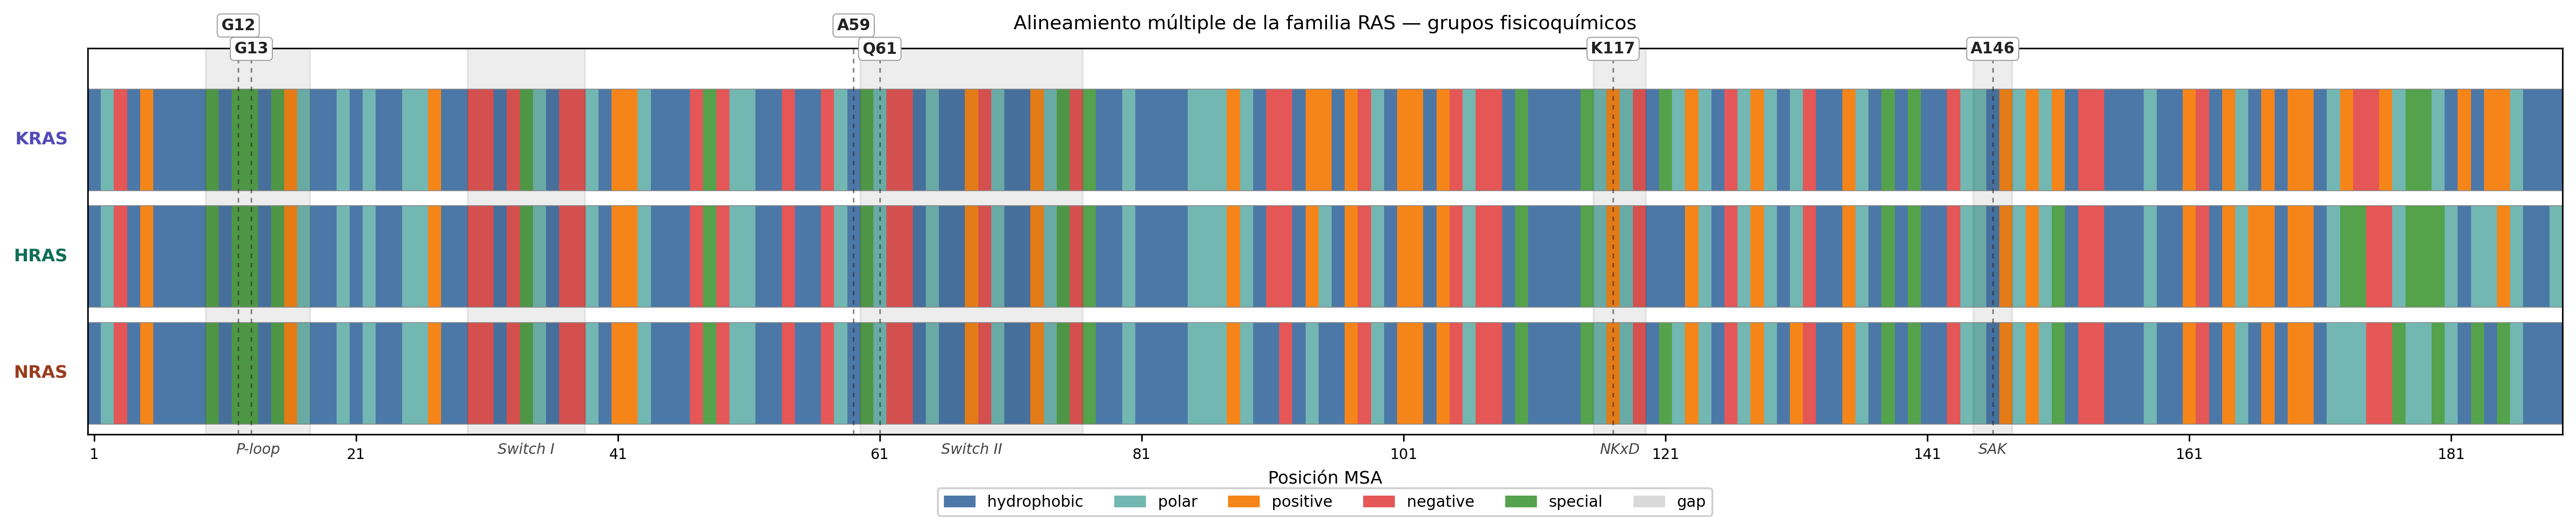

In [21]:
# ============================================================
# CHUNK 10.2: Mostrar la figura del MSA en el notebook
# ============================================================

# IPython.display.Image permite mostrar una imagen desde disco directamente en el notebook.
# Es la forma correcta de mostrar una figura que ya ha sido guardada en disco por Matplotlib.
# No usamos plt.show() porque visualize_msa() ya cerro la figura con plt.close().
from IPython.display import Image, display  # Funciones de visualizacion de IPython

# Image() carga la imagen desde disco.
# width=1200 limita el ancho a 1200 pixeles para que quepa en la pantalla del notebook.
display(Image(filename=str(output_fig_path), width=1200))

## 11. Identificacion de posiciones recurrentemente mutadas

Una posicion se considera **recurrentemente mutada** si aparece mutada en al menos `min_members` isoformas con un minimo de `min_samples` muestras tumorales en cada una. Este criterio biologico refleja la **presion selectiva convergente**:

> Si tres genes distintos (KRAS, HRAS, NRAS) adquieren mutaciones en la misma posicion estructural en tumores independientes de diferentes pacientes, esa posicion tiene **relevancia funcional critica** y probablemente forme parte del sitio activo o de una interfaz proteina-proteina.

Los umbrales de la configuracion del proyecto son:
- `recurrent_min_members`: numero minimo de isoformas con mutaciones en esa posicion.
- `recurrent_min_samples_per_member`: numero minimo de muestras tumorales por isoforma.

La funcion `find_recurrent_positions()` itera sobre cada fila del mapa posicional, consulta el dataset de mutaciones curadas para cada isoforma y posicion, y devuelve un DataFrame ordenado por numero total de muestras mutadas (descendente).

Se espera que los hotspots **G12, G13 y Q61** aparezcan en los primeros puestos, dado que acumulan el mayor numero de muestras mutadas en la base de datos COSMIC.

In [22]:
# ============================================================
# CHUNK 11.1: Encontrar posiciones recurrentemente mutadas
# ============================================================

# find_recurrent_positions() necesita:
#   - mutations_df: el DataFrame de mutaciones curadas con columnas gene, position,
#                   sample_count y hgvs_p (exactamente las columnas de cosmic_curated.csv).
#   - position_map: el mapa posicional construido en el paso anterior.
#   - min_members:  umbral del config para el numero de isoformas
#   - min_samples:  umbral del config para el numero de muestras por isoforma
#
# Devuelve un DataFrame ordenado por total_samples descendente.
recurrent = find_recurrent_positions(
    curated,       # DataFrame de mutaciones curadas con columnas: gene, position, sample_count, hgvs_p
    position_map,  # Mapa posicional del MSA
    min_members=MIN_MEMBERS,  # Minimo de isoformas mutadas (del config)
    min_samples=MIN_SAMPLES,  # Minimo de muestras por isoforma (del config)
)

print(f"[OK] Analisis de posiciones recurrentes completado.")
print(f"  Parametros usados:")
print(f"    min_members  : {MIN_MEMBERS} (min. isoformas mutadas por posicion)")
print(f"    min_samples  : {MIN_SAMPLES} (min. muestras por isoforma)")
print()
print(f"  Posiciones recurrentes encontradas: {len(recurrent)}")

if recurrent.empty:
    print("  [WARN] No se encontraron posiciones recurrentes con los umbrales actuales.")
    print("  Considera reducir min_members o min_samples en configs/config.yaml.")

[OK] Analisis de posiciones recurrentes completado.
  Parametros usados:
    min_members  : 2 (min. isoformas mutadas por posicion)
    min_samples  : 10 (min. muestras por isoforma)

  Posiciones recurrentes encontradas: 6


## 12. Guardar las posiciones recurrentes en formato CSV

El fichero `data/processed/recurrent_positions.csv` contiene las posiciones recurrentemente mutadas con todas sus coordenadas (posicion en el MSA, posicion en cada isoforma, numero de muestras, mutaciones mas frecuentes). Este fichero sera el punto de partida para el analisis estructural del hito siguiente.

In [23]:
# ============================================================
# CHUNK 12.1: Guardar las posiciones recurrentes en CSV
# ============================================================

# to_csv() escribe el DataFrame de posiciones recurrentes en disco.
# index=False: no incluir el indice numerico de pandas en el fichero de salida.
# Incluso si recurrent esta vacio, to_csv() crea el fichero con las cabeceras.
recurrent.to_csv(RECURRENT_PATH, index=False)

print(f"[OK] Posiciones recurrentes guardadas en: {RECURRENT_PATH}")
print(f"  Filas escritas: {len(recurrent)}")
if RECURRENT_PATH.exists():
    print(f"  Tamano del fichero: {RECURRENT_PATH.stat().st_size:,} bytes")

[OK] Posiciones recurrentes guardadas en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/recurrent_positions.csv
  Filas escritas: 6
  Tamano del fichero: 494 bytes


## 13. Tabla resumen de posiciones recurrentes

La tabla siguiente muestra todas las posiciones recurrentemente mutadas con sus coordenadas en cada isoforma RAS. Las columnas mas importantes son:

- `msa_position`: columna del alineamiento (referencia universal para comparar entre isoformas).
- `kras_pos`, `hras_pos`, `nras_pos`: posicion 1-based en cada isoforma (puede ser `NaN` si hay gap).
- `n_members_mutated`: cuantas isoformas tienen mutaciones en esta posicion con frecuencia suficiente.
- `total_samples`: suma de muestras tumorales en las tres isoformas.
- `top_mutations`: la mutacion mas frecuente de cada isoforma en esta posicion.

Se espera que G12, G13 y Q61 encabecen la tabla, dado que concentran la mayoria de los casos de cancer RAS-mutado en COSMIC. Estos tres hotspots afectan directamente al mecanismo de hidrolisis del GTP y estan presentes en las tres isoformas porque la presion selectiva del cancer los favorece repetidamente de forma independiente.

In [24]:
# ============================================================
# CHUNK 13.1: Mostrar la tabla de posiciones recurrentes
# ============================================================

if recurrent.empty:
    # Si no hay posiciones recurrentes, avisar al usuario con instrucciones claras.
    print("[WARN] No se encontraron posiciones recurrentes.")
    print("  Posibles causas:")
    print("  1. El dataset curado no tiene suficientes mutaciones (comprueba cosmic_curated.csv).")
    print("  2. Los umbrales min_members o min_samples son demasiado altos.")
    print("  3. Las columnas del dataset curado no tienen los nombres esperados.")
else:
    print(f"Tabla de posiciones recurrentemente mutadas ({len(recurrent)} posiciones):")
    print("Ordenadas por total de muestras tumorales (descendente)\n")

    # Mostrar la tabla completa con todas las posiciones recurrentes.
    # En Jupyter, el ultimo objeto de la celda se renderiza automaticamente como tabla HTML.
    display(recurrent)

Tabla de posiciones recurrentemente mutadas (6 posiciones):
Ordenadas por total de muestras tumorales (descendente)



,msa_position,kras_pos,hras_pos,nras_pos,n_members_mutated,total_samples,kras_samples,hras_samples,nras_samples,top_mutations
0,12,12,12,12,3,12487,11564,195,728,KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
1,13,13,13,13,3,2604,1917,323,364,KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
2,61,61,61,61,3,2424,542,365,1517,KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R
3,146,146,146,146,2,361,346,3,12,KRAS:p.A146T|NRAS:p.A146T
4,117,117,117,117,2,121,104,16,1,KRAS:p.K117N|HRAS:p.K117N
5,59,59,59,59,2,81,60,9,12,KRAS:p.A59T|NRAS:p.A59T


In [28]:
# ============================================================
# CHUNK 13.2: Analisis detallado de los hotspots principales
# ============================================================

if not recurrent.empty:
    # Mostrar estadisticas resumidas de las posiciones recurrentes.
    print("Estadisticas de posiciones recurrentes:")
    print("-" * 50)

    # Distribucion por numero de isoformas mutadas.
    # value_counts() cuenta cuantas posiciones tienen 2 isoformas mutadas, cuantas 3, etc.
    print("Distribucion por n_members_mutated:")
    print(recurrent["n_members_mutated"].value_counts().sort_index().to_string())
    print()

    # Mostrar el detalle de las 6 posiciones mas frecuentes.
    # .head(6) toma las 6 primeras filas (ya estan ordenadas por total_samples descendente).
    print("Top 6 posiciones por total de muestras tumorales:")
    print("-" * 70)
    top6 = recurrent.head(6)
    for _, row in top6.iterrows():
        # .iterrows() devuelve pares (indice, Serie) para cada fila del DataFrame.
        # row es una Serie donde cada campo es accesible por nombre.
        print(f"  Posicion MSA {int(row['msa_position']):3d} | "
              f"KRAS:{int(row['kras_pos']) if pd.notna(row['kras_pos']) else 'N/A':>3} | "
              f"HRAS:{int(row['hras_pos']) if pd.notna(row['hras_pos']) else 'N/A':>3} | "
              f"NRAS:{int(row['nras_pos']) if pd.notna(row['nras_pos']) else 'N/A':>3} | "
              f"Total muestras: {int(row['total_samples']):>6,} | "
              f"Mutaciones: {row['top_mutations']}")

Estadisticas de posiciones recurrentes:
--------------------------------------------------
Distribucion por n_members_mutated:
n_members_mutated
2    3
3    3

Top 6 posiciones por total de muestras tumorales:
----------------------------------------------------------------------
  Posicion MSA  12 | KRAS: 12 | HRAS: 12 | NRAS: 12 | Total muestras: 12,487 | Mutaciones: KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
  Posicion MSA  13 | KRAS: 13 | HRAS: 13 | NRAS: 13 | Total muestras:  2,604 | Mutaciones: KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
  Posicion MSA  61 | KRAS: 61 | HRAS: 61 | NRAS: 61 | Total muestras:  2,424 | Mutaciones: KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R
  Posicion MSA 146 | KRAS:146 | HRAS:146 | NRAS:146 | Total muestras:    361 | Mutaciones: KRAS:p.A146T|NRAS:p.A146T
  Posicion MSA 117 | KRAS:117 | HRAS:117 | NRAS:117 | Total muestras:    121 | Mutaciones: KRAS:p.K117N|HRAS:p.K117N
  Posicion MSA  59 | KRAS: 59 | HRAS: 59 | NRAS: 59 | Total muestras:     81 | Mutaciones: KRAS:p.A59T|N

In [26]:
# ============================================================
# CHUNK 13.3: Verificar presencia de G12, G13 y Q61 en recurrentes
# ============================================================

# Verificar que los hotspots esperados (G12, G13, Q61) aparecen en la tabla de recurrentes.
# Si el dataset tiene suficientes datos, estos tres deben estar presentes.
print("Verificacion de hotspots en posiciones recurrentes:")
print("-" * 50)

for position, aa in hotspots_to_check:
    if recurrent.empty:
        print(f"  {aa}{position}: [WARN] Tabla vacia, no se puede verificar.")
        continue

    # Buscar la posicion del hotspot en la tabla de recurrentes usando kras_pos.
    # .eq(position) compara elemento a elemento de forma segura con NaN.
    found = recurrent.loc[recurrent["kras_pos"].eq(position)]

    if found.empty:
        print(f"  {aa}{position}: [WARN] No encontrado como posicion recurrente ")
        print(f"         (puede requerir umbrales mas bajos o mas datos en COSMIC).")
    else:
        # Obtener los datos de la fila encontrada
        row = found.iloc[0]
        print(f"  {aa}{position}: [OK] MSA col={int(row['msa_position'])}, "
              f"total_samples={int(row['total_samples']):,}, "
              f"isoformas={int(row['n_members_mutated'])}, "
              f"top_mutations={row['top_mutations']}")

Verificacion de hotspots en posiciones recurrentes:
--------------------------------------------------
  G12: [OK] MSA col=12, total_samples=12,487, isoformas=3, top_mutations=KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
  G13: [OK] MSA col=13, total_samples=2,604, isoformas=3, top_mutations=KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
  Q61: [OK] MSA col=61, total_samples=2,424, isoformas=3, top_mutations=KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R


## Resumen del Hito 2

Este notebook ha completado el **Hito 2** del TFM con los siguientes resultados:

### Artefactos generados

| Fichero | Descripcion |
|---------|-------------|
| `data/processed/msa_ras.fasta` | Alineamiento multiple de KRAS, HRAS y NRAS en formato FASTA |
| `data/processed/position_map.csv` | Mapa de equivalencias posicion-a-posicion entre las tres isoformas |
| `data/processed/recurrent_positions.csv` | Posiciones recurrentemente mutadas en 2 o mas isoformas |
| `figures/02_msa_overview.png` | Visualizacion coloreada del MSA con regiones funcionales |

### Conclusiones biologicas

1. **Alta conservacion**: las tres isoformas RAS comparten mas del 85 % de identidad de secuencia en el dominio catalytico G, confirmando su origen como genes paralogos.

2. **Sin gaps en el dominio catalytico**: las tres secuencias tienen exactamente 189 residuos, lo que permite un alineamiento directo sin necesidad de introducir gaps. Esto simplifica considerablemente la comparacion de posiciones entre isoformas.

3. **Hotspots perfectamente alineados**: los residuos G12, G13 y Q61 se encuentran en la misma columna del MSA y tienen el mismo aminoacido (Gly o Gln) en las tres isoformas, lo que confirma que son posiciones funcionalmente equivalentes.

4. **Recurrencia pan-RAS**: G12, G13 y Q61 aparecen como las posiciones mas recurrentemente mutadas en las tres isoformas simultaneamente, lo que los convierte en dianas prioritarias para el diseno de inhibidores pan-RAS.

### Proximos pasos (Hito 3)

El notebook 03 utilizara el mapa posicional y las posiciones recurrentes de este hito para:

- Descargar las estructuras cristalograficas de KRAS, HRAS y NRAS del Protein Data Bank (PDB).
- Mapear las posiciones mutadas del MSA a los residuos de las estructuras tridimensionales.
- Calcular propiedades estructurales (accesibilidad al solvente, factores de temperatura B, distancia al GTP) para cada posicion recurrente.

In [27]:
# ============================================================
# CHUNK FINAL: Resumen de ficheros generados
# ============================================================

# Mostrar un resumen de todos los ficheros generados en este notebook,
# con sus rutas absolutas y tamanos para facilitar la verificacion.
print("Ficheros generados por el Hito 2:")
print("=" * 65)

# Lista de tuplas (descripcion, ruta) de los ficheros de salida
output_files = [
    ("MSA en formato FASTA",          MSA_OUTPUT_PATH),
    ("Mapa posicional CSV",            POSITION_MAP_PATH),
    ("Posiciones recurrentes CSV",     RECURRENT_PATH),
    ("Figura del MSA (PNG)",           FIGURE_MSA_PATH),
]

for description, path in output_files:
    # Comprobar si el fichero existe y obtener su tamano
    if path.exists():
        size_kb = path.stat().st_size / 1024  # Convertir bytes a kilobytes
        print(f"  [OK] {description:<30} {size_kb:6.1f} KB")
        print(f"       {path}")
    else:
        print(f"  [FAIL] {description:<30} NO ENCONTRADO")
        print(f"         {path}")
    print()

print("[OK] Hito 2 completado exitosamente.")

Ficheros generados por el Hito 2:
  [OK] MSA en formato FASTA              0.6 KB
       /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/msa_ras.fasta

  [OK] Mapa posicional CSV               4.7 KB
       /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/position_map.csv

  [OK] Posiciones recurrentes CSV        0.5 KB
       /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/recurrent_positions.csv

  [OK] Figura del MSA (PNG)            117.9 KB
       /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/02_msa_overview.png

[OK] Hito 2 completado exitosamente.
